<a href="https://colab.research.google.com/github/Nerneri/Historical_Stock_Market_FP/blob/kira/fudan_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Historical Stock Market**

The dataset used in this lab is available on Kaggle at the following link:

https://www.kaggle.com/datasets/asafusa553/stocks-open-close-rsi-bb-percentage-and-more?resource=download

Historical Stock Market Dataset with Technical Indicators (2015 – Present)

**Description:** This dataset contains daily historical stock market data for multiple US equities starting from January 1, 2015. It includes lots of data, as well as widely-used technical indicators and derived features, making it ready for quantitative analysis, trading strategy development, or machine learning applications.

**Features included:**

Column Description

Date Trading date (YYYY-MM-DD)

Ticker Stock symbol

Open Opening price for the trading day

RSI 14-day Relative Strength Index

Dist_to_BB_top Distance from the upper Bollinger Band to the opening price
 (BB_top - Open)
Dist_to_BB_bottom Distance from the lower Bollinger Band to the opening price\(BB_bottom - Open)
SMA20 20-day Simple Moving Average of closing prices

ATR 14-day Average True Range

PCT_1d_ago – PCT_5d_ago Percentage price change over the last 1–5 days

Volume_1d_ago – Volume_5d_ago Trading volume for the last 1–5 days

**Highlights:**

Covers multiple tickers(~631) from 2015 to present.

All rows with missing values removed to ensure a clean dataset.

Distances to Bollinger Bands are calculated relative to the opening price.

**Usage Notes:**

Ideal for machine learning applications requiring fully preprocessed input features.

Users can easily expand the dataset with additional tickers or extend historical data.

License: Free for use (MIT).

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
data = pd.read_parquet('/content/drive/MyDrive/fudan_project/data.parquet')

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529034 entries, 0 to 1529033
Data columns (total 18 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Date               1529034 non-null  object 
 1   Ticker             1529034 non-null  object 
 2   Open               1529034 non-null  float64
 3   RSI                1529034 non-null  float64
 4   Dist_to_BB_top     1529034 non-null  float64
 5   Dist_to_BB_bottom  1529034 non-null  float64
 6   SMA20              1529034 non-null  float64
 7   ATR                1529034 non-null  float64
 8   PCT_1d_ago         1529034 non-null  float64
 9   PCT_2d_ago         1529034 non-null  float64
 10  PCT_3d_ago         1529034 non-null  float64
 11  PCT_4d_ago         1529034 non-null  float64
 12  PCT_5d_ago         1529034 non-null  float64
 13  Volume_1d_ago      1529034 non-null  float64
 14  Volume_2d_ago      1529034 non-null  float64
 15  Volume_3d_ago      1529034 non-n

In [ ]:
data.head(10)

,Date,Ticker,Open,RSI,Dist_to_BB_top,Dist_to_BB_bottom,SMA20,ATR,PCT_1d_ago,PCT_2d_ago,PCT_3d_ago,PCT_4d_ago,PCT_5d_ago,Volume_1d_ago,Volume_2d_ago,Volume_3d_ago,Volume_4d_ago,Volume_5d_ago
0,2015-01-30,PAYX,46.150002,31.124486,2.437439,-0.601441,47.0680,0.967857,-2.414840,-3.455637,-5.055590,-6.060610,-6.448951,2919100.0,2472000.0,1740500.0,1531000.0,2061100.0
1,2015-02-02,PAYX,45.439999,40.035568,3.170278,0.057725,47.0540,0.905714,1.546621,-0.905567,-1.962462,-3.587160,-4.607724,3166000.0,2919100.0,2472000.0,1740500.0,1531000.0
2,2015-02-03,PAYX,46.430000,48.706226,2.173130,-0.866130,47.0835,0.880000,2.067016,3.645607,1.142731,0.063991,-1.594291,3180800.0,3166000.0,2919100.0,2472000.0,1740500.0
3,2015-02-04,PAYX,46.810001,49.475265,1.757639,-1.102641,47.1375,0.860000,0.341078,2.415145,3.999119,1.487707,0.405287,2921200.0,3180800.0,3166000.0,2919100.0,2472000.0
4,2015-02-05,PAYX,47.169998,52.916069,1.431225,-1.430221,47.1705,0.866429,0.892292,1.236414,3.328987,4.927096,2.393274,2252900.0,2921200.0,3180800.0,3166000.0,2919100.0
5,2015-02-06,PAYX,47.540001,53.049643,1.081438,-1.803439,47.1790,0.872857,0.505365,1.402167,1.748027,3.851176,5.457360,2387800.0,2252900.0,2921200.0,3180800.0,3166000.0
6,2015-02-09,PAYX,47.650002,49.295760,0.990962,-1.902965,47.1940,0.863572,-0.607586,-0.105292,0.786061,1.129820,3.220191,2277500.0,2387800.0,2252900.0,2921200.0,3180800.0
7,2015-02-10,PAYX,47.490002,53.918926,1.228862,-1.735865,47.2365,0.867143,1.032887,0.419025,0.926508,1.827067,2.174377,1966900.0,2277500.0,2387800.0,2252900.0,2921200.0
8,2015-02-11,PAYX,47.919998,51.424505,0.906573,-2.165570,47.2905,0.823572,0.479866,1.517709,0.900902,1.410819,2.315700,1426100.0,1966900.0,2277500.0,2387800.0,2252900.0
9,2015-02-12,PAYX,48.200001,50.218969,0.766952,-2.458954,47.3540,0.798572,0.519103,1.001460,2.044691,1.424681,1.937246,1088300.0,1426100.0,1966900.0,2277500.0,2387800.0


<Axes: >

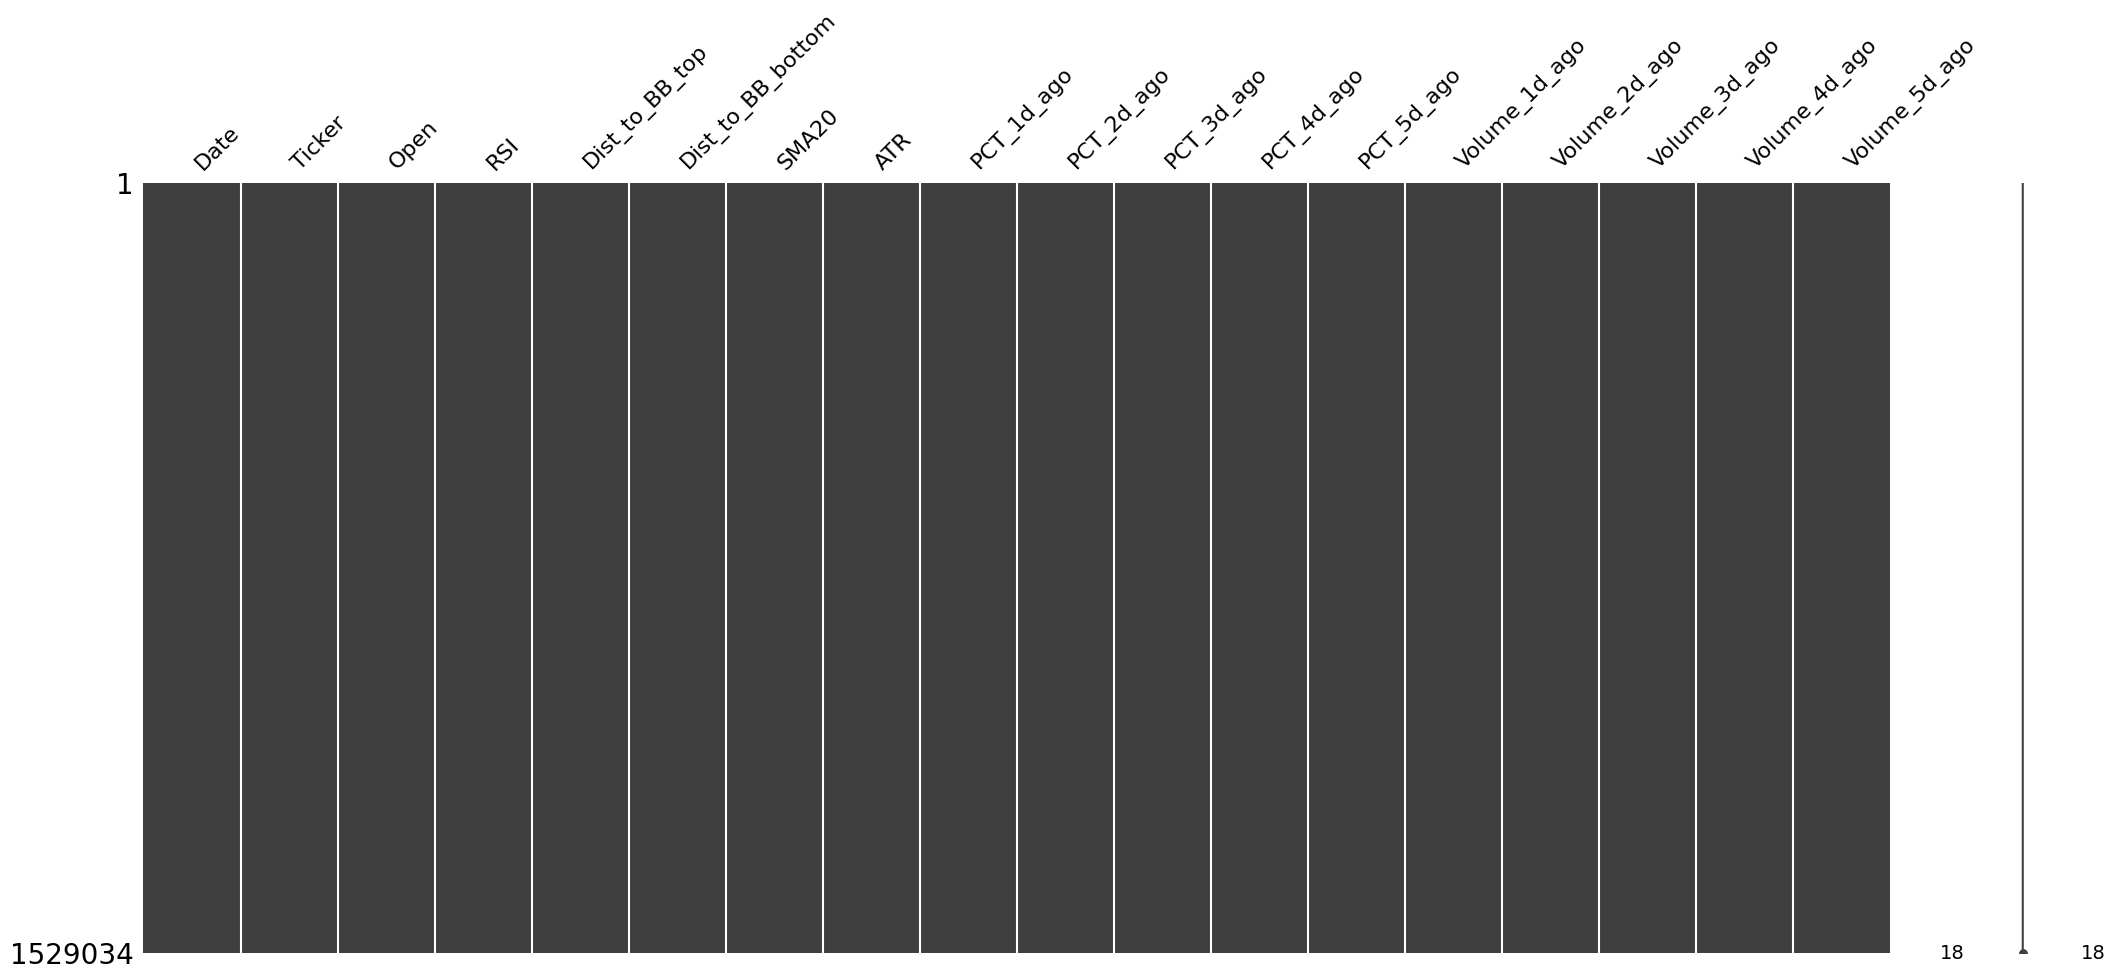

In [ ]:
missingno.matrix(data)

# **TODO: explain info above**




---



# **Q1. Deeper Insights.**

### What kind of feature do you find from the data? What kind of feature do you think is important for predicting the stock prices?

# **TODO**

### *I. from the data we found that all the data that data set provides can be devided inro four main groups:*

1. **fleeting and trend things**:
- SMA20, which establishes the baseline short-term trend
- RSI, which measures the velocity and magnitude of recent price changes to evaluate overvalued or undervalued conditions
2. **bands**:
- Dist_to_BB_top and Dist_to_BB_bottom how far the opening price has stretched beyond its standard deviation boundarie, we use it for identifying extremes in price action
3. **volatility**:
- ATR, that captures the absolute amplitude of market noise and price swings, regardless of direction
4. **lags**:
- from PCT_1d_ago to PCT_5d_ago: the history of percentage price changes over the previous week, it allows the model to capture inertia: whether the stock has been rising for several days in a row (strong momentum) or if the growth is fading out (an imminent pullback)
- from Volume_1d_ago to Volume_5d_ago, it's a truth detector for price moves, high volume behind a price rise means heavy institutional buying (strong signal), while low volume means the move is likely random market noise


### *II. features important for predicting stock prices:*
-




---



# **Q2. Prediction.**

### Based upon your analysis, which features do you think are most important for predicting the stock prices? And implement a model to predict the stock prices. You can use any model you want, but you need to explain why you choose that model and how you implement it. You also need to evaluate your model and explain the results.

# **TODO**



---



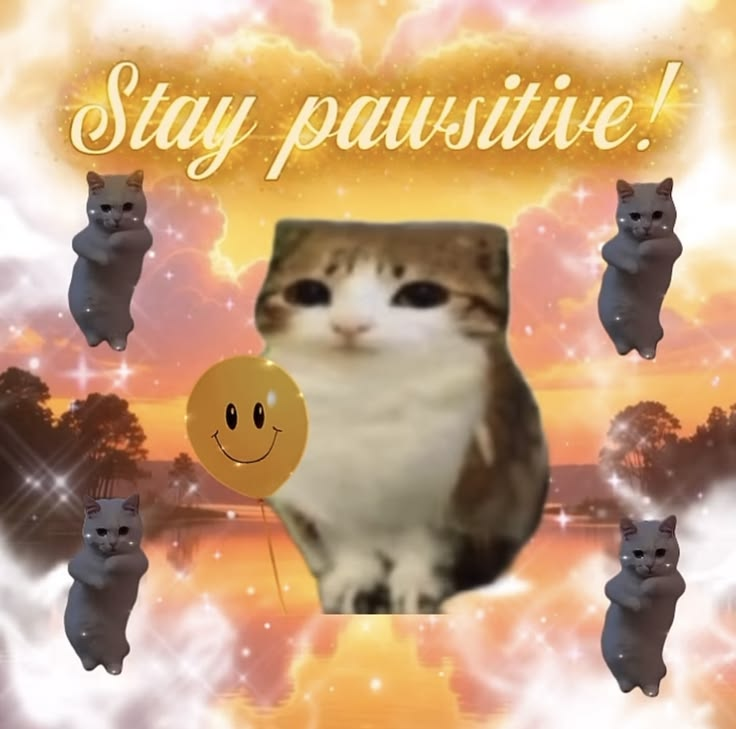